# Segmentação de Rotas Aéreas com K-Means

Este notebook implementa uma análise de clusterização de rotas aéreas utilizando o algoritmo K-Means.
O objetivo é identificar grupos de rotas com características similares baseadas em:
- **Atraso médio** de partida
- **Distância média** da rota
- **Frequência** de voos por rota

Dataset: 2015 Flight Delays and Cancellations (Kaggle)

## 1. Importação das Bibliotecas

Importamos as bibliotecas necessárias para manipulação de dados, modelagem e visualização.

In [1]:
# Bibliotecas para manipulação de dados
import pandas as pd
import numpy as np

# Bibliotecas para pré-processamento e modelagem
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

# Bibliotecas para visualização
import matplotlib.pyplot as plt
import seaborn as sns

# Configurações de visualização
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_palette('husl')
%matplotlib inline

# Ignora warnings para uma saída mais limpa
import warnings
warnings.filterwarnings('ignore')

print("Bibliotecas importadas com sucesso!")

Bibliotecas importadas com sucesso!


## 2. Carregamento dos Dados

Carregamos o dataset de voos. Por ser um arquivo grande, selecionamos apenas as colunas necessárias para otimizar a memória.

In [2]:
# Define as colunas relevantes para nossa análise
# Isso reduz o uso de memória ao carregar apenas o necessário
colunas_necessarias = [
    'ORIGIN_AIRPORT',       # Aeroporto de origem
    'DESTINATION_AIRPORT',  # Aeroporto de destino
    'DEPARTURE_DELAY',      # Atraso na partida (em minutos)
    'ARRIVAL_DELAY',        # Atraso na chegada (em minutos)
    'DISTANCE'              # Distância do voo (em milhas)
]

# Carrega o dataset
df_flights = pd.read_csv('data/flights.csv', usecols=colunas_necessarias)

print(f"Dataset carregado com {len(df_flights):,} voos")
print(f"\nColunas disponíveis: {df_flights.columns.tolist()}")
df_flights.head()

Dataset carregado com 5,819,079 voos

Colunas disponíveis: ['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT', 'DEPARTURE_DELAY', 'DISTANCE', 'ARRIVAL_DELAY']


,ORIGIN_AIRPORT,DESTINATION_AIRPORT,DEPARTURE_DELAY,DISTANCE,ARRIVAL_DELAY
0,ANC,SEA,-11.0,1448,-22.0
1,LAX,PBI,-8.0,2330,-9.0
2,SFO,CLT,-2.0,2296,5.0
3,LAX,MIA,-5.0,2342,-9.0
4,SEA,ANC,-1.0,1448,-21.0


In [3]:
# Verifica informações básicas do dataset
print("Informações do Dataset:")
print("=" * 50)
df_flights.info()
print("\nEstatísticas Descritivas:")
df_flights.describe()

Informações do Dataset:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5819079 entries, 0 to 5819078
Data columns (total 5 columns):
 #   Column               Dtype  
---  ------               -----  
 0   ORIGIN_AIRPORT       object 
 1   DESTINATION_AIRPORT  object 
 2   DEPARTURE_DELAY      float64
 3   DISTANCE             int64  
 4   ARRIVAL_DELAY        float64
dtypes: float64(2), int64(1), object(2)
memory usage: 222.0+ MB

Estatísticas Descritivas:


,DEPARTURE_DELAY,DISTANCE,ARRIVAL_DELAY
count,5.732926e+06,5.819079e+06,5.714008e+06
mean,9.370158e+00,8.223565e+02,4.407057e+00
std,3.708094e+01,6.077843e+02,3.927130e+01
min,-8.200000e+01,2.100000e+01,-8.700000e+01
25%,-5.000000e+00,3.730000e+02,-1.300000e+01
50%,-2.000000e+00,6.470000e+02,-5.000000e+00
75%,7.000000e+00,1.062000e+03,8.000000e+00
max,1.988000e+03,4.983000e+03,1.971000e+03


## 3. Engenharia de Features

### Por que agrupar por rota?
Cada combinação única de ORIGIN_AIRPORT + DESTINATION_AIRPORT representa uma **rota**.
Agregamos os dados para obter métricas representativas de cada rota:

- **avg_delay**: Média de atraso na partida → indica a pontualidade típica da rota
- **avg_distance**: Distância média → caracteriza se é rota curta, média ou longa
- **flight_count**: Frequência de voos → indica a popularidade/demanda da rota

In [4]:
# Agrupa os dados por rota (origem + destino)
# Cada linha do resultado representa uma rota única
df_routes = df_flights.groupby(['ORIGIN_AIRPORT', 'DESTINATION_AIRPORT']).agg(
    avg_delay=('DEPARTURE_DELAY', 'mean'),      # Média de atraso na partida
    avg_distance=('DISTANCE', 'mean'),          # Média da distância (deve ser constante por rota)
    flight_count=('DISTANCE', 'count')          # Contagem de voos = frequência da rota
).reset_index()

print(f"Total de rotas únicas identificadas: {len(df_routes):,}")
print(f"\nPrimeiras 10 rotas:")
df_routes.head(10)

Total de rotas únicas identificadas: 12,377

Primeiras 10 rotas:


,ORIGIN_AIRPORT,DESTINATION_AIRPORT,avg_delay,avg_distance,flight_count
0,10135,10397,6.662651,692.0,83
1,10135,11433,15.225352,425.0,71
2,10135,13930,8.930556,655.0,72
3,10136,11298,3.368132,158.0,189
4,10140,10397,-0.209302,1269.0,86
5,10140,10821,3.896552,1670.0,58
6,10140,11259,7.248175,580.0,137
7,10140,11292,8.386667,349.0,150
8,10140,11298,7.760234,569.0,174
9,10140,12191,3.578313,759.0,83


In [5]:
# Estatísticas descritivas das features agregadas
print("Estatísticas das Features por Rota:")
print("=" * 50)
df_routes[['avg_delay', 'avg_distance', 'flight_count']].describe()

Estatísticas das Features por Rota:


,avg_delay,avg_distance,flight_count
count,12366.000000,12377.00000,12377.000000
mean,7.870061,902.63334,470.152622
std,15.218620,672.59677,995.169205
min,-26.000000,21.00000,1.000000
25%,0.659237,419.00000,9.000000
50%,5.910293,738.00000,75.000000
75%,10.902125,1157.00000,443.000000
max,341.000000,4983.00000,13744.000000


## 4. Pré-processamento dos Dados

### 4.1 Tratamento de Valores Nulos
Valores nulos podem surgir quando não há dados de atraso para algumas rotas.
Removemos essas rotas para garantir a qualidade da clusterização.

In [6]:
# Verifica a quantidade de valores nulos antes do tratamento
print("Valores Nulos por Coluna (ANTES do tratamento):")
print(df_routes.isnull().sum())
print(f"\nTotal de rotas: {len(df_routes):,}")

Valores Nulos por Coluna (ANTES do tratamento):
ORIGIN_AIRPORT          0
DESTINATION_AIRPORT     0
avg_delay              11
avg_distance            0
flight_count            0
dtype: int64

Total de rotas: 12,377


In [7]:
# Remove rotas com valores nulos
# Optamos por remover em vez de imputar para manter a integridade dos dados
# (rotas sem dados de atraso não fornecem informação útil para clusterização)
df_routes_clean = df_routes.dropna()

print(f"Rotas removidas por valores nulos: {len(df_routes) - len(df_routes_clean):,}")
print(f"Rotas restantes para análise: {len(df_routes_clean):,}")

# Verifica se ainda existem valores nulos
print("\nValores Nulos por Coluna (APÓS tratamento):")
print(df_routes_clean.isnull().sum())

Rotas removidas por valores nulos: 11
Rotas restantes para análise: 12,366

Valores Nulos por Coluna (APÓS tratamento):
ORIGIN_AIRPORT         0
DESTINATION_AIRPORT    0
avg_delay              0
avg_distance           0
flight_count           0
dtype: int64


### 4.2 Normalização dos Dados com StandardScaler

### Por que normalizar?
O algoritmo K-Means utiliza a **distância euclidiana** para calcular a proximidade entre pontos.
Sem normalização:
- `flight_count` pode variar de 1 a milhares
- `avg_distance` varia de ~100 a ~5000 milhas
- `avg_delay` varia de ~-10 a ~30 minutos

Features com maior escala dominariam o cálculo de distância, enviesando os clusters.
O **StandardScaler** transforma cada feature para ter média=0 e desvio padrão=1.

In [8]:
# Seleciona apenas as features numéricas para clusterização
features = ['avg_delay', 'avg_distance', 'flight_count']
X = df_routes_clean[features].values

print("Dados ANTES da normalização:")
print(f"  avg_delay    - Média: {X[:, 0].mean():.2f}, Std: {X[:, 0].std():.2f}")
print(f"  avg_distance - Média: {X[:, 1].mean():.2f}, Std: {X[:, 1].std():.2f}")
print(f"  flight_count - Média: {X[:, 2].mean():.2f}, Std: {X[:, 2].std():.2f}")

Dados ANTES da normalização:
  avg_delay    - Média: 7.87, Std: 15.22
  avg_distance - Média: 902.62, Std: 672.57
  flight_count - Média: 470.57, Std: 995.47


In [9]:
# Aplica o StandardScaler para normalizar os dados
# Cada feature terá média ≈ 0 e desvio padrão ≈ 1
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

print("Dados APÓS a normalização:")
print(f"  avg_delay    - Média: {X_scaled[:, 0].mean():.6f}, Std: {X_scaled[:, 0].std():.2f}")
print(f"  avg_distance - Média: {X_scaled[:, 1].mean():.6f}, Std: {X_scaled[:, 1].std():.2f}")
print(f"  flight_count - Média: {X_scaled[:, 2].mean():.6f}, Std: {X_scaled[:, 2].std():.2f}")
print("\n✓ Agora todas as features têm a mesma escala!")

Dados APÓS a normalização:
  avg_delay    - Média: 0.000000, Std: 1.00
  avg_distance - Média: 0.000000, Std: 1.00
  flight_count - Média: 0.000000, Std: 1.00

✓ Agora todas as features têm a mesma escala!


## 5. Método do Cotovelo (Elbow Method)

### Como funciona?
O método do cotovelo nos ajuda a escolher o número ideal de clusters (k).

**Inércia** = Soma das distâncias quadradas de cada ponto ao centroide do seu cluster.
- Quanto menor a inércia, mais compactos são os clusters
- Porém, mais clusters sempre reduzem a inércia (no limite, k=n tem inércia=0)

**O "cotovelo"** é o ponto onde adicionar mais clusters para de trazer ganho significativo.
É o equilíbrio entre complexidade (muitos clusters) e qualidade (clusters compactos).

In [10]:
# Calcula a inércia para diferentes valores de k
inertias = []
K_range = range(1, 11)  # Testa k de 1 a 10

print("Calculando inércia para cada valor de k...")
for k in K_range:
    # random_state=42 garante reprodutibilidade dos resultados
    # n_init=10 executa o algoritmo 10 vezes com diferentes centroides iniciais
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(X_scaled)
    inertias.append(kmeans.inertia_)
    print(f"  k={k:2d} → Inércia: {kmeans.inertia_:,.2f}")

Calculando inércia para cada valor de k...
  k= 1 → Inércia: 37,098.00
  k= 2 → Inércia: 28,750.24
  k= 3 → Inércia: 20,906.45
  k= 4 → Inércia: 14,415.34
  k= 5 → Inércia: 12,363.74
  k= 6 → Inércia: 10,462.47
  k= 7 → Inércia: 8,726.98
  k= 8 → Inércia: 7,802.53
  k= 9 → Inércia: 7,140.37
  k=10 → Inércia: 6,482.76


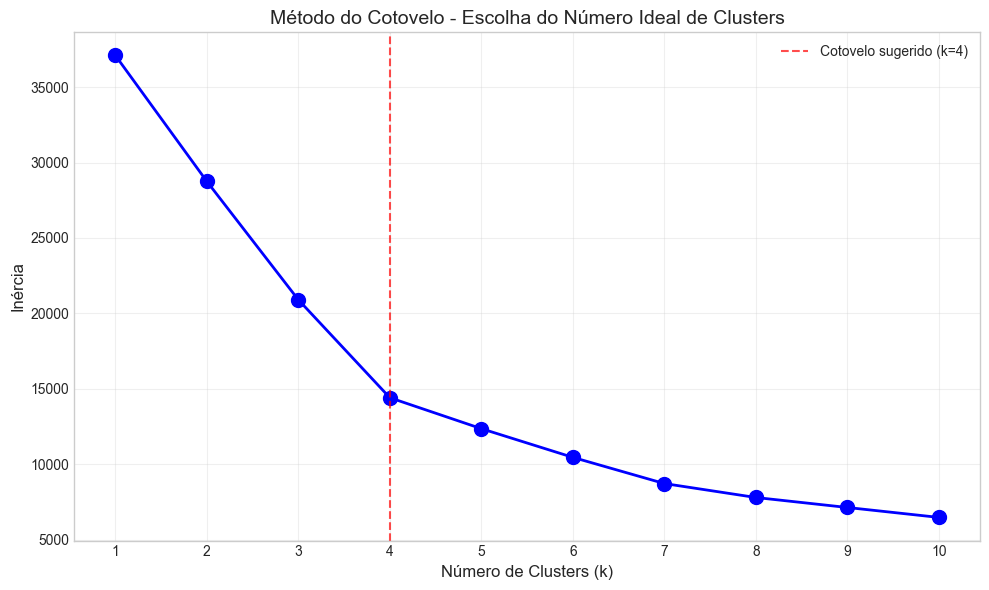


📊 Análise do Gráfico:
   - A inércia diminui rapidamente até k=3 ou k=4
   - Após k=4, a redução é mais gradual (retornos decrescentes)
   - k=4 parece ser um bom ponto de equilíbrio (cotovelo)


In [11]:
# Plota o gráfico do método do cotovelo
plt.figure(figsize=(10, 6))

plt.plot(K_range, inertias, 'bo-', linewidth=2, markersize=10)
plt.xlabel('Número de Clusters (k)', fontsize=12)
plt.ylabel('Inércia', fontsize=12)
plt.title('Método do Cotovelo - Escolha do Número Ideal de Clusters', fontsize=14)
plt.xticks(K_range)
plt.grid(True, alpha=0.3)

# Marca o ponto sugerido do cotovelo (k=4)
plt.axvline(x=4, color='red', linestyle='--', alpha=0.7, label='Cotovelo sugerido (k=4)')
plt.legend()

plt.tight_layout()
plt.show()

print("\n📊 Análise do Gráfico:")
print("   - A inércia diminui rapidamente até k=3 ou k=4")
print("   - Após k=4, a redução é mais gradual (retornos decrescentes)")
print("   - k=4 parece ser um bom ponto de equilíbrio (cotovelo)")

## 6. Modelagem Final com K-Means

Baseado no método do cotovelo, definimos **k=4** clusters para a segmentação das rotas.

In [12]:
# Define o número de clusters baseado na análise do cotovelo
N_CLUSTERS = 4

# Treina o modelo K-Means final
kmeans_final = KMeans(
    n_clusters=N_CLUSTERS,
    random_state=42,       # Reprodutibilidade
    n_init=10,             # 10 inicializações diferentes
    max_iter=300           # Máximo de 300 iterações por inicialização
)

# Aplica o modelo aos dados normalizados
clusters = kmeans_final.fit_predict(X_scaled)

# Adiciona os clusters ao dataframe original
df_routes_clean = df_routes_clean.copy()  # Evita warning de SettingWithCopyWarning
df_routes_clean['cluster'] = clusters

print(f"✓ Modelo K-Means treinado com {N_CLUSTERS} clusters")
print(f"\nDistribuição das rotas por cluster:")
print(df_routes_clean['cluster'].value_counts().sort_index())

✓ Modelo K-Means treinado com 4 clusters

Distribuição das rotas por cluster:
cluster
0    8805
1    2336
2     917
3     308
Name: count, dtype: int64


In [13]:
# Analisa as características de cada cluster
print("=" * 70)
print("PERFIL DE CADA CLUSTER (valores médios)")
print("=" * 70)

cluster_profile = df_routes_clean.groupby('cluster').agg({
    'avg_delay': 'mean',
    'avg_distance': 'mean',
    'flight_count': 'mean',
    'ORIGIN_AIRPORT': 'count'  # Contagem de rotas por cluster
}).rename(columns={'ORIGIN_AIRPORT': 'num_routes'})

cluster_profile = cluster_profile.round(2)
print(cluster_profile)
print("\n")

PERFIL DE CADA CLUSTER (valores médios)
         avg_delay  avg_distance  flight_count  num_routes
cluster                                                   
0             5.50        627.84        250.44        8805
1             6.69       2005.43        241.61        2336
2            10.21        740.95       3323.53         917
3            77.65        874.97          6.13         308




In [14]:
# Interpretação dos clusters
print("=" * 70)
print("INTERPRETAÇÃO DOS CLUSTERS")
print("=" * 70)

# Ordena clusters por característica principal para nomear
for cluster_id in sorted(df_routes_clean['cluster'].unique()):
    stats = cluster_profile.loc[cluster_id]
    
    # Classifica o cluster baseado em suas características
    delay_level = "alto" if stats['avg_delay'] > 10 else "moderado" if stats['avg_delay'] > 5 else "baixo"
    distance_level = "longa" if stats['avg_distance'] > 1500 else "média" if stats['avg_distance'] > 800 else "curta"
    freq_level = "alta" if stats['flight_count'] > 1000 else "média" if stats['flight_count'] > 200 else "baixa"
    
    print(f"\n📍 Cluster {cluster_id}:")
    print(f"   - {int(stats['num_routes'])} rotas")
    print(f"   - Atraso médio: {stats['avg_delay']:.1f} min ({delay_level})")
    print(f"   - Distância média: {stats['avg_distance']:.0f} milhas ({distance_level})")
    print(f"   - Frequência média: {stats['flight_count']:.0f} voos ({freq_level})")

INTERPRETAÇÃO DOS CLUSTERS

📍 Cluster 0:
   - 8805 rotas
   - Atraso médio: 5.5 min (moderado)
   - Distância média: 628 milhas (curta)
   - Frequência média: 250 voos (média)

📍 Cluster 1:
   - 2336 rotas
   - Atraso médio: 6.7 min (moderado)
   - Distância média: 2005 milhas (longa)
   - Frequência média: 242 voos (média)

📍 Cluster 2:
   - 917 rotas
   - Atraso médio: 10.2 min (alto)
   - Distância média: 741 milhas (curta)
   - Frequência média: 3324 voos (alta)

📍 Cluster 3:
   - 308 rotas
   - Atraso médio: 77.7 min (alto)
   - Distância média: 875 milhas (média)
   - Frequência média: 6 voos (baixa)


## 7. Visualizações

### 7.1 Scatterplot: Distância vs. Atraso por Cluster

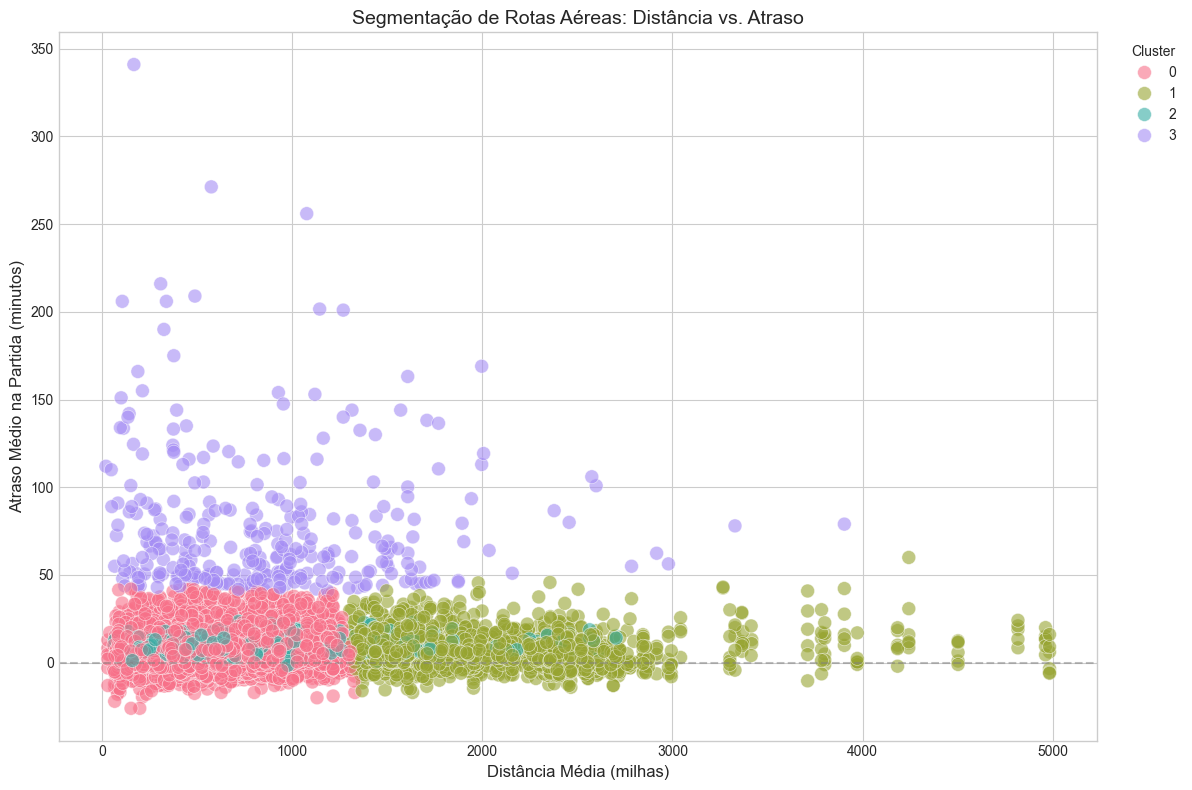

In [15]:
# Cria o scatterplot principal: Distância vs Atraso
plt.figure(figsize=(12, 8))

# Usa paleta de cores distintas para cada cluster
palette = sns.color_palette('husl', N_CLUSTERS)

# Scatterplot com cores por cluster
scatter = sns.scatterplot(
    data=df_routes_clean,
    x='avg_distance',
    y='avg_delay',
    hue='cluster',
    palette=palette,
    s=100,           # Tamanho dos pontos
    alpha=0.6,       # Transparência para visualizar sobreposições
    edgecolor='white',
    linewidth=0.5
)

# Configurações do gráfico
plt.xlabel('Distância Média (milhas)', fontsize=12)
plt.ylabel('Atraso Médio na Partida (minutos)', fontsize=12)
plt.title('Segmentação de Rotas Aéreas: Distância vs. Atraso', fontsize=14)

# Melhora a legenda
plt.legend(title='Cluster', bbox_to_anchor=(1.02, 1), loc='upper left')

# Adiciona linha de referência em atraso = 0
plt.axhline(y=0, color='gray', linestyle='--', alpha=0.5, label='Sem atraso')

plt.tight_layout()
plt.show()

### 7.2 Visualização com Tamanho por Frequência

Esta visualização adiciona uma terceira dimensão: o **tamanho dos pontos** representa a frequência de voos da rota.

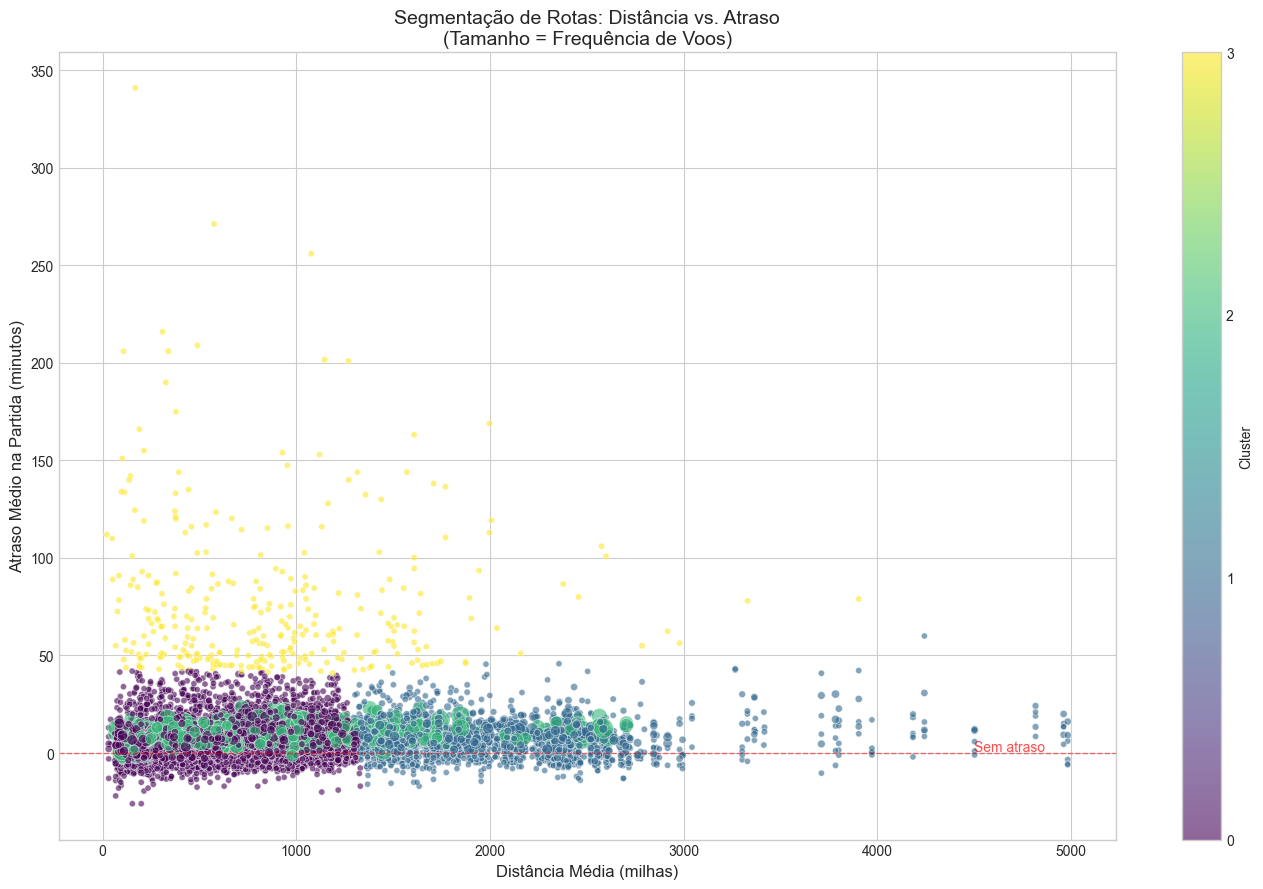

In [16]:
# Scatterplot com tamanho proporcional à frequência
plt.figure(figsize=(14, 9))

# Normaliza o tamanho dos pontos para melhor visualização
sizes = df_routes_clean['flight_count'] / df_routes_clean['flight_count'].max() * 300 + 20

scatter = plt.scatter(
    df_routes_clean['avg_distance'],
    df_routes_clean['avg_delay'],
    c=df_routes_clean['cluster'],
    cmap='viridis',
    s=sizes,
    alpha=0.6,
    edgecolors='white',
    linewidth=0.5
)

# Adiciona colorbar
cbar = plt.colorbar(scatter, label='Cluster')
cbar.set_ticks(range(N_CLUSTERS))

plt.xlabel('Distância Média (milhas)', fontsize=12)
plt.ylabel('Atraso Médio na Partida (minutos)', fontsize=12)
plt.title('Segmentação de Rotas: Distância vs. Atraso\n(Tamanho = Frequência de Voos)', fontsize=14)

# Linha de referência
plt.axhline(y=0, color='red', linestyle='--', alpha=0.5, linewidth=1)
plt.text(4500, 1, 'Sem atraso', fontsize=10, color='red', alpha=0.7)

plt.tight_layout()
plt.show()

### 7.3 Boxplots Comparativos por Cluster

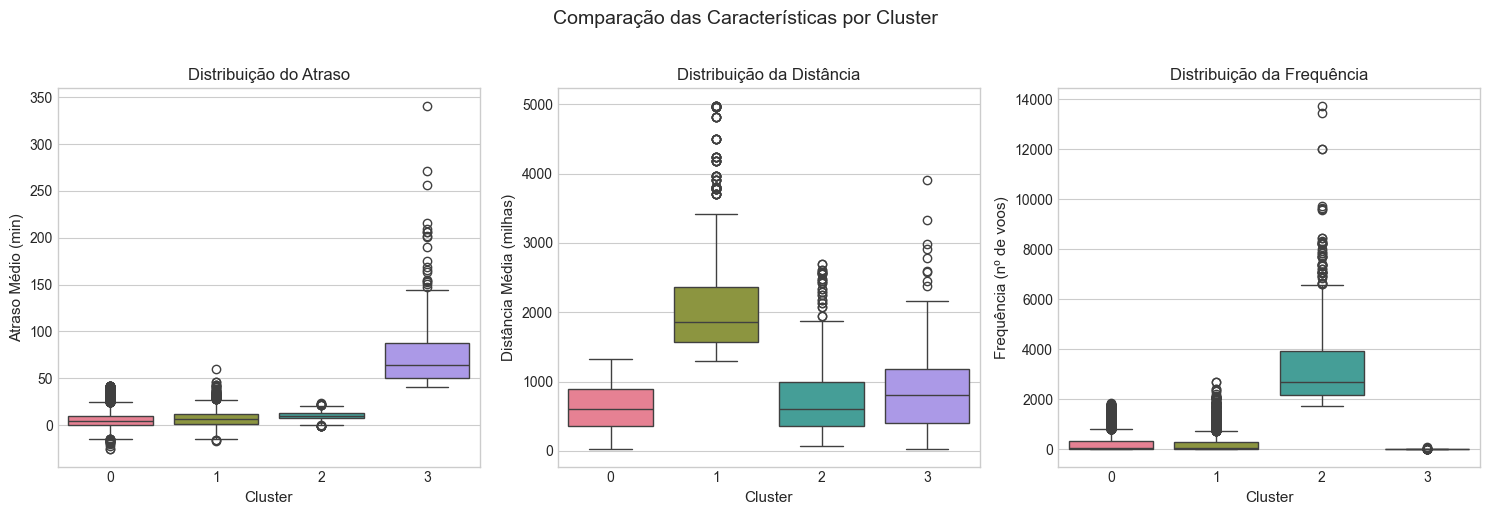

In [17]:
# Cria uma figura com 3 subplots para comparar as features por cluster
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

# Boxplot 1: Atraso por Cluster
sns.boxplot(data=df_routes_clean, x='cluster', y='avg_delay', ax=axes[0], palette='husl')
axes[0].set_xlabel('Cluster', fontsize=11)
axes[0].set_ylabel('Atraso Médio (min)', fontsize=11)
axes[0].set_title('Distribuição do Atraso', fontsize=12)

# Boxplot 2: Distância por Cluster
sns.boxplot(data=df_routes_clean, x='cluster', y='avg_distance', ax=axes[1], palette='husl')
axes[1].set_xlabel('Cluster', fontsize=11)
axes[1].set_ylabel('Distância Média (milhas)', fontsize=11)
axes[1].set_title('Distribuição da Distância', fontsize=12)

# Boxplot 3: Frequência por Cluster
sns.boxplot(data=df_routes_clean, x='cluster', y='flight_count', ax=axes[2], palette='husl')
axes[2].set_xlabel('Cluster', fontsize=11)
axes[2].set_ylabel('Frequência (nº de voos)', fontsize=11)
axes[2].set_title('Distribuição da Frequência', fontsize=12)

plt.suptitle('Comparação das Características por Cluster', fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

### 7.4 Heatmap dos Centroides

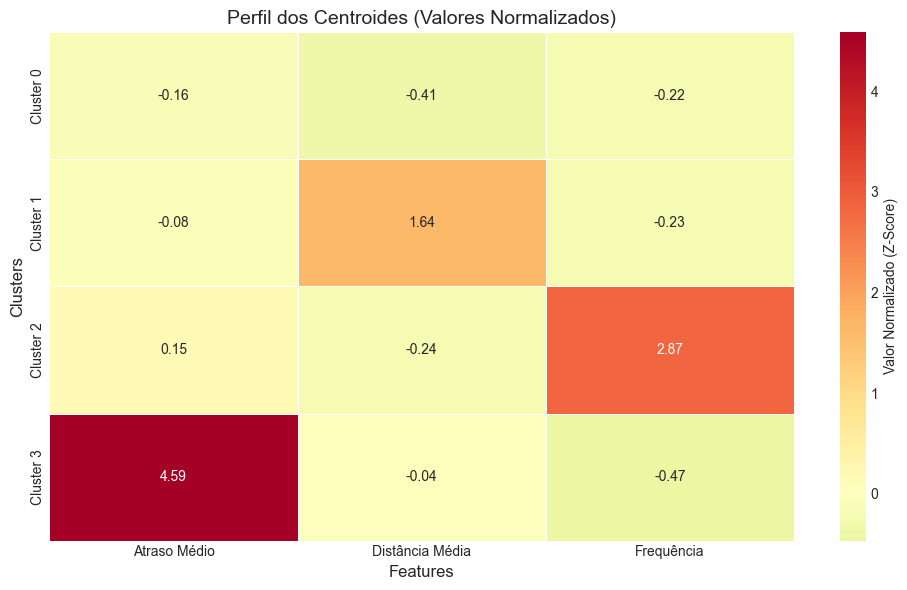


📊 Interpretação do Heatmap:
   - Valores POSITIVOS (vermelho): acima da média geral
   - Valores NEGATIVOS (verde): abaixo da média geral
   - Valores próximos de 0 (amarelo): próximos à média


In [18]:
# Visualiza os centroides em um heatmap
# Isso mostra claramente o "perfil" de cada cluster

# Obtém os centroides (em escala normalizada)
centroids_scaled = kmeans_final.cluster_centers_

# Cria dataframe para visualização
df_centroids = pd.DataFrame(
    centroids_scaled,
    columns=['Atraso Médio', 'Distância Média', 'Frequência'],
    index=[f'Cluster {i}' for i in range(N_CLUSTERS)]
)

plt.figure(figsize=(10, 6))
sns.heatmap(
    df_centroids,
    annot=True,
    fmt='.2f',
    cmap='RdYlGn_r',
    center=0,
    linewidths=0.5,
    cbar_kws={'label': 'Valor Normalizado (Z-Score)'}
)

plt.title('Perfil dos Centroides (Valores Normalizados)', fontsize=14)
plt.xlabel('Features', fontsize=12)
plt.ylabel('Clusters', fontsize=12)

plt.tight_layout()
plt.show()

print("\n📊 Interpretação do Heatmap:")
print("   - Valores POSITIVOS (vermelho): acima da média geral")
print("   - Valores NEGATIVOS (verde): abaixo da média geral")
print("   - Valores próximos de 0 (amarelo): próximos à média")

## 8. Exemplos de Rotas por Cluster

In [19]:
# Exibe exemplos de rotas de cada cluster
print("=" * 70)
print("EXEMPLOS DE ROTAS POR CLUSTER")
print("=" * 70)

for cluster_id in sorted(df_routes_clean['cluster'].unique()):
    print(f"\n🔹 CLUSTER {cluster_id}:")
    sample = df_routes_clean[df_routes_clean['cluster'] == cluster_id].nlargest(5, 'flight_count')
    
    for _, row in sample.iterrows():
        print(f"   {row['ORIGIN_AIRPORT']} → {row['DESTINATION_AIRPORT']}: "
              f"{row['flight_count']:,} voos, "
              f"{row['avg_distance']:.0f} mi, "
              f"atraso médio {row['avg_delay']:.1f} min")

EXEMPLOS DE ROTAS POR CLUSTER

🔹 CLUSTER 0:
   PDX → SEA: 1,849 voos, 129 mi, atraso médio 3.4 min
   CLE → MDW: 1,823 voos, 307 mi, atraso médio 6.8 min
   BUF → BWI: 1,808 voos, 281 mi, atraso médio 9.2 min
   IAH → TUL: 1,805 voos, 429 mi, atraso médio 4.5 min
   TUL → IAH: 1,800 voos, 429 mi, atraso médio 3.3 min

🔹 CLUSTER 1:
   OGG → LAX: 2,711 voos, 2486 mi, atraso médio 10.4 min
   LAX → OGG: 2,708 voos, 2486 mi, atraso médio 10.3 min
   LAX → MCO: 2,417 voos, 2218 mi, atraso médio 8.6 min
   MCO → LAX: 2,414 voos, 2218 mi, atraso médio 12.5 min
   PHX → JFK: 2,327 voos, 2153 mi, atraso médio 12.6 min

🔹 CLUSTER 2:
   SFO → LAX: 13,744 voos, 337 mi, atraso médio 12.6 min
   LAX → SFO: 13,457 voos, 337 mi, atraso médio 14.1 min
   JFK → LAX: 12,016 voos, 2475 mi, atraso médio 8.0 min
   LAX → JFK: 12,015 voos, 2475 mi, atraso médio 10.7 min
   LAS → LAX: 9,715 voos, 236 mi, atraso médio 11.3 min

🔹 CLUSTER 3:
   JFK → EGE: 110 voos, 1746 mi, atraso médio 47.0 min
   FAI → ORD: 7

## 9. Salvando os Resultados

In [20]:
# Salva o dataframe com os clusters para uso posterior
df_routes_clean.to_csv('data/routes_clustered.csv', index=False)
print("✓ Resultados salvos em 'data/routes_clustered.csv'")

# Resumo final
print("\n" + "=" * 70)
print("RESUMO DA ANÁLISE")
print("=" * 70)
print(f"• Total de voos analisados: {len(df_flights):,}")
print(f"• Total de rotas únicas: {len(df_routes_clean):,}")
print(f"• Número de clusters: {N_CLUSTERS}")
print(f"• Inércia final: {kmeans_final.inertia_:,.2f}")

✓ Resultados salvos em 'data/routes_clustered.csv'

RESUMO DA ANÁLISE
• Total de voos analisados: 5,819,079
• Total de rotas únicas: 12,366
• Número de clusters: 4
• Inércia final: 14,415.34


## 10. Conclusões

### Principais Insights:

1. **Segmentação clara**: O K-Means conseguiu identificar grupos distintos de rotas baseados em suas características operacionais.

2. **Padrões identificados**:
   - Rotas curtas e frequentes (regionais/shuttle)
   - Rotas longas com baixa frequência (transcontinentais)
   - Rotas com alto índice de atraso (possíveis gargalos operacionais)
   - Rotas eficientes com baixo atraso

3. **Aplicações práticas**:
   - **Gestão de capacidade**: Identificar rotas que precisam de mais recursos
   - **Análise de pontualidade**: Focar melhorias nas rotas com maior atraso
   - **Estratégia comercial**: Segmentar ofertas por tipo de rota
   - **Otimização operacional**: Entender padrões de atraso por característica da rota

### Próximos Passos:
- Incluir mais features (ex: horário do dia, dia da semana, companhia aérea)
- Testar outros algoritmos de clusterização (DBSCAN, Hierarchical)
- Validar clusters com métricas como Silhouette Score